# Главные компоненты + k соседей

Испорчено Алёной

# Знакомство с датасетом

Пример кода scikit-learn
Пример применения PCA к датасету Iris для уменьшения размерности:


In [9]:
 # Импорт библиотек
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.datasets import load_iris

Датасет Ирисы

* Petal – лепестки
* Sepal – чашелистники


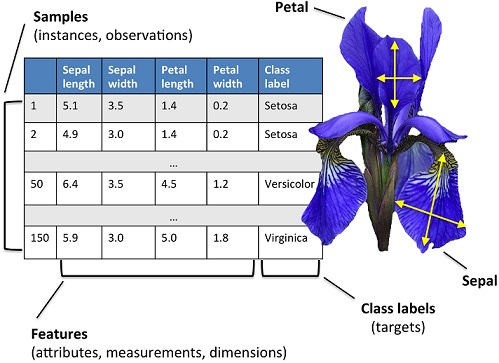

In [10]:
 # Загрузка данных
centers = [[1, 1], [-1, -1], [1, -1]]
iris = datasets.load_iris()

X = iris.data
y = iris.target

In [11]:
#X


In [12]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


iris.data — это те самые 150×4 числа, а iris.feature_names — названия столбцов (sepal length (cm) и т.д.)

In [14]:
# Импортируем необходимые библиотеки
# import pandas as pd
# import numpy as np
# from sklearn.datasets import load_iris

# Загружаем датасет
iris = load_iris()

# Создаем DataFrame для удобства работы
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
iris_df['number']=iris.target

# Посмотрим на первые 5 строк датасета
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  number  
0  setosa       0  
1  setosa       0  
2  setosa       0  
3  setosa       0  
4  setosa       0  


In [15]:
# Базовый статистический анализ
print(iris_df.describe())

# Проверка наличия пропущенных значений
print(iris_df.isnull().sum())

# Распределение классов
print(iris_df['species'].value_counts())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      number  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
pet

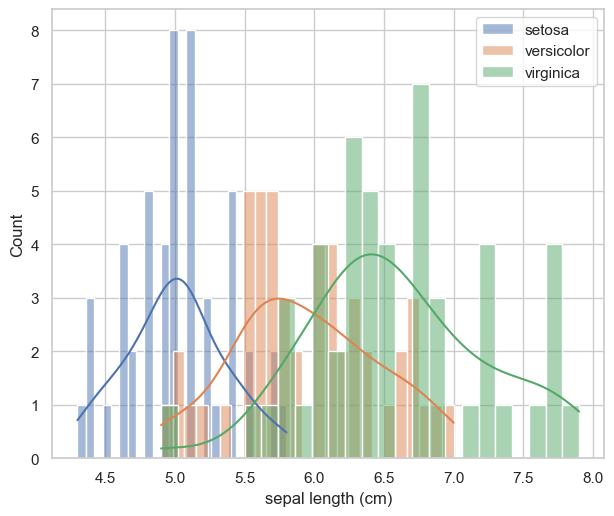

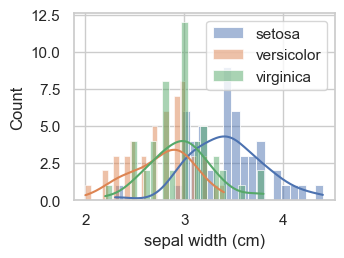

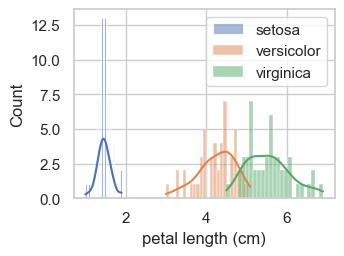

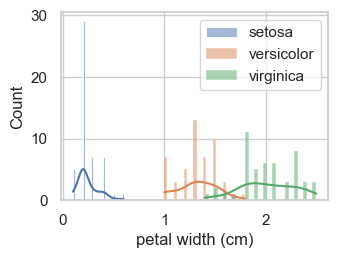

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль визуализации
sns.set_theme(style="whitegrid")

# Создаем гистограммы для каждого признака
plt.figure(figsize=(12, 10))
for i, feature in enumerate(iris.feature_names):
  plt.subplot(2, 2, i+1)
  for species in iris.target_names:
    subset = iris_df[iris_df['species'] == species]
    sns.histplot(subset[feature], label=species, kde=True, bins=25)
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
  plt.show()

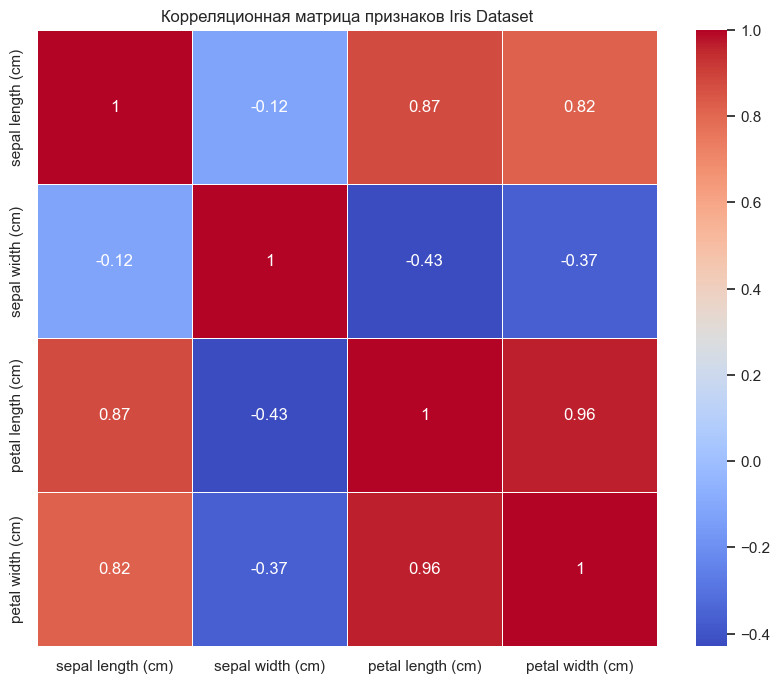

In [17]:
# Корреляционная тепловая карта
plt.figure(figsize=(10, 8))
corr = iris_df.drop(['species', 'number'], axis=1).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Корреляционная матрица признаков Iris Dataset")
plt.show()

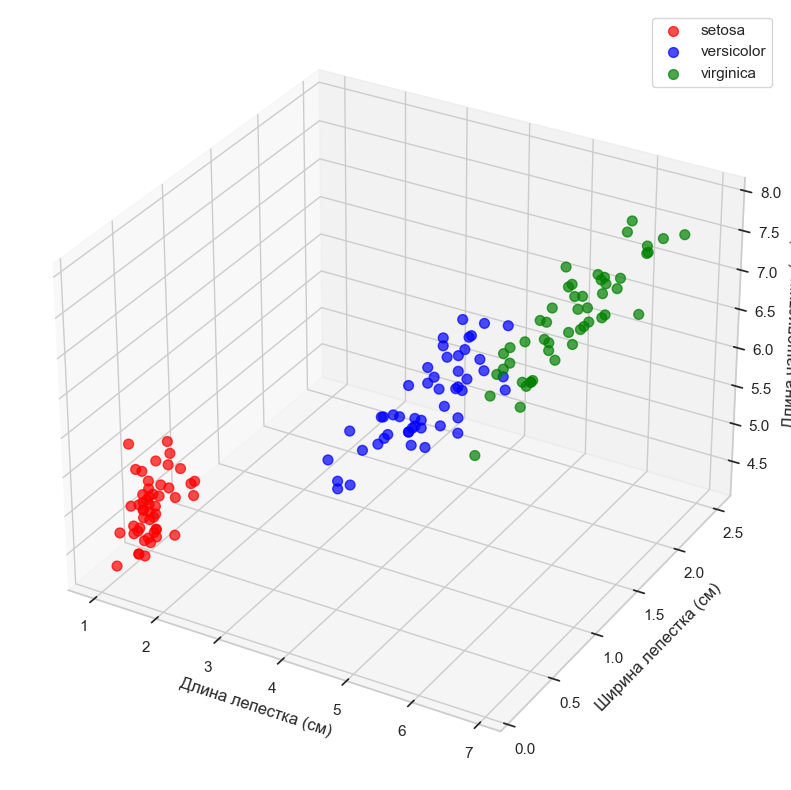

In [18]:
# 3D визуализация
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Выбираем три наиболее информативных признака
x = iris_df['petal length (cm)']
y = iris_df['petal width (cm)']
z = iris_df['sepal length (cm)']

# Цвета для разных классов
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

# Наносим точки на график
for species in iris.target_names:
  idx = iris_df['species'] == species
  ax.scatter(x[idx], y[idx], z[idx], c=colors[species], label=species, s=50, alpha=0.7)

ax.set_xlabel('Длина лепестка (см)')
ax.set_ylabel('Ширина лепестка (см)')
ax.set_zlabel('Длина чашелистика (см)')
ax.legend()
#ax.view_init(azim=60)
plt.show()

# К соседей

Метод k ближайших соседей (англ. k-nearest neighbors algorithm, k-NN) — метрический алгоритм для автоматической классификации объектов или регрессии.

В случае использования метода для классификации объект присваивается тому классу, который является наиболее распространённым среди k соседей данного элемента, классы которых уже известны. В случае использования метода для регрессии, объекту присваивается среднее значение по k ближайшим к нему объектам, значения которых уже известны.

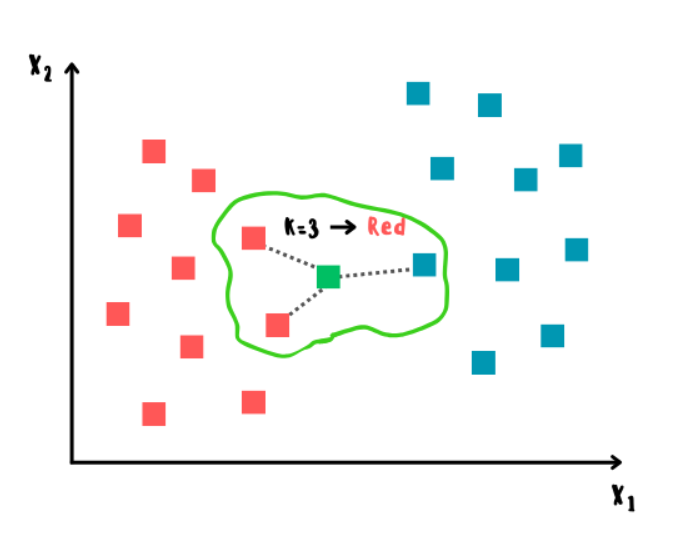

**Нормализация** применяется когда величины признаков измеряются в слишком разных единицах (напр., один – в сантиметрах, другой – метрах).

Минимакс-нормализация осуществляется следующим образом:
$$
x' = \frac{x - min[X]}{max[X] - min[X]}
$$

в этом случае все значения будут лежать в диапазоне от 0 до 1; дискретные бинарные значения определяются как 0 и 1.

Z-нормализация:
$$
x' = \frac{x-X_{сред}}{\sigma[X]}
$$
где 
$\sigma[X]$ — среднеквадратичное отклонение признака Х; в этом случае большинство значений попадёт в диапазон $ (-3 \sigma; 3 \sigma). \ X_{сред}, \ \sigma[X]$ – считаются по тренировочным данным. 

**Применяемые нормы:**

$\lVert x \rVert_1 = \sum\limits_{i=1}^n \lvert x_i \rvert$ - Манхэттэнская норма

$\lVert x \rVert_2 = \sqrt{\sum\limits_{i=1}^n x_i^2}$ - Евклидова норма

$\lVert x \rVert_p = \sqrt[p]{\sum\limits_{i=1}^n x_i^p}$ - норма Минковского

$\lVert x \rVert_\infty = \max\limits_i \lvert x_i \rvert$ - норма Чебышева

## Создание своего алгоритма и обучение модели 

Разобьем данные на тренировочный и тестовый датасеты и для простоты реализации алгоритма объединим массивы признаков объектов и метки их классов, чтобы было понятно, к какому классу относится каждый объект.


In [42]:
from sklearn.model_selection import train_test_split

size = 64

x_train, x_test, y_train, y_test = train_test_split(iris.data[:, [0,2,3]],
                                                    iris['target'],
                                                    train_size=size,
                                                    random_state=808) # random_state - для воспроизводимости

print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (64, 3), y_train shape: (64,),
X_test shape: (86, 3), y_test shape: (86,)


In [43]:
x_train_concat = np.concatenate((x_train, y_train.reshape(size, 1)), axis=1)
x_test_concat = np.concatenate((x_test, y_test.reshape(150-size, 1)), axis=1)
print(f'X_train shape: {x_train_concat.shape},\n'
      f'X_test shape: {x_test_concat.shape}')

X_train shape: (64, 4),
X_test shape: (86, 4)


In [44]:
pd.DataFrame(x_train_concat).head(5)

,0,1,2,3
0,5.4,1.5,0.2,0.0
1,4.4,1.3,0.2,0.0
2,7.1,5.9,2.1,2.0
3,6.9,5.7,2.3,2.0
4,4.7,1.3,0.2,0.0


### Вычисление растояний до точек и отбор k соседей

In [22]:
norms = {"Манхэттэнская" : 1, "Евклидова" : 2, "Минковского" : 3, "Чебышева" : np.inf}
norm_type = "Евклидова"   #какую норму хотим использовать

In [45]:
def get_neighbors(train, test, norm, k=5):
    distances = [(train[i][-1], np.linalg.norm(train[i][:-1] - test[:-1], ord=norm))
                  for i in range (len(train))]  # список кортежей (сорт, расстояние до него)
    distances.sort(key=lambda elem: elem[1])

    neighbors = [distances[i][0] for i in range (k)]
    return neighbors

### Прогноз на основе классов соседей

Теперь получим прогноз на основе классов соседей. Посчитаем, сколько объектов каждого класса присутствует среди  k  ближайших к целевому, и затем причислим его к тому классу, экземпляров которого больше всего.

In [46]:
def prediction(neighbors):
    count = {}
    for instance in neighbors:
        if instance in count:
            count[instance] +=1
        else :
            count[instance] = 1
    target = max(count.items(), key=lambda x: x[1])[0]
    return target

Напишем последнюю функцию для оценки точности прогнозов - это просто отношение верных прогнозов к общему количеству прогнозов.

In [47]:
def accuracy(test, test_prediction):
    correct = 0
    for i in range (len(test)):
        if test[i][-1] == test_prediction[i]:
            correct += 1
    return (correct / len(test))

### Сравнение результатов

In [48]:
predictions = []
for x in range (len(x_test_concat)):
    neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms[norm_type], k=5)
    result = prediction(neighbors)
    predictions.append(result)
acc = accuracy(x_test_concat, predictions)
print(f'Accuracy: {acc}')

Accuracy: 0.9418604651162791


Импортируем и обучаем модель

In [49]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

knn_model = knn.fit(x_train, y_train)

knn_predictions = knn.predict(x_test)
knn_predictions

array([0, 0, 2, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1, 0,
       2, 1, 1, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0,
       0, 0, 0, 0, 0, 1, 1, 2, 1, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 0, 1, 1,
       1, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [50]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, knn_predictions)
print(f'Accuracy: {acc}')

Accuracy: 0.9418604651162791


## Подбор параметров k соседей

Подбираем количество оцениваемых соседей и используемую метрику.

### Подбор параметров для рукописного алгоритма

Есть негласное правило: k должно быть значительно меньше размера обучающей выборки, обычно не больше √n. При n=40 это k ≤ 6 примерно.

In [51]:
norms = {"Манхэттэнская" : 1, "Евклидова" : 2, "Минковского" : 3, "Чебышева" : np.inf}

In [52]:
#predictions_1 = dict()
accur_per_norm = {"Манхэттэнская" : [], "Евклидова" : [], "Минковского" : [], "Чебышева" : []}

for norm in norms:
    for k in range(1, 21):
        predictions_temp = list()
        for x in range (len(x_test_concat)):
            neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms[norm], k)
            result = prediction(neighbors)
            predictions_temp.append(result)
        accur_per_norm[norm].append(accuracy(x_test_concat, predictions_temp))

#accur_per_norm

In [53]:
import pprint

# pprint заставляет всё быть компактнее
pprint.pprint(accur_per_norm, width=100, compact=True)

{'Евклидова': [0.9418604651162791, 0.9418604651162791, 0.9418604651162791, 0.9418604651162791,
               0.9418604651162791, 0.9418604651162791, 0.9651162790697675, 0.9418604651162791,
               0.9534883720930233, 0.9418604651162791, 0.9767441860465116, 0.9534883720930233,
               0.9651162790697675, 0.9534883720930233, 0.9534883720930233, 0.9651162790697675,
               0.9534883720930233, 0.9651162790697675, 0.9767441860465116, 0.9651162790697675],
 'Манхэттэнская': [0.9418604651162791, 0.9418604651162791, 0.9302325581395349, 0.9418604651162791,
                   0.9418604651162791, 0.9418604651162791, 0.9534883720930233, 0.9534883720930233,
                   0.9534883720930233, 0.9534883720930233, 0.9534883720930233, 0.9534883720930233,
                   0.9767441860465116, 0.9534883720930233, 0.9651162790697675, 0.9651162790697675,
                   0.9651162790697675, 0.9651162790697675, 0.9418604651162791, 0.9534883720930233],
 'Минковского': [0.941860465

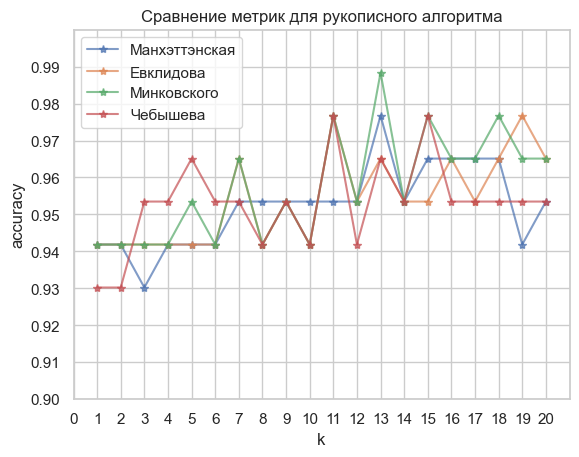

In [54]:
#for norm in norms:
#    plt.plot(range(1, 21), accur_per_norm[norm], marker='*', markersize=6, alpha=0.7, label=norm)
plt.plot(range(1, 21), accur_per_norm["Манхэттэнская"], marker='*', markersize=6, alpha=0.7, label="Манхэттэнская")
plt.plot(range(1, 21), accur_per_norm["Евклидова"], marker='*', markersize=6, alpha=0.7, label="Евклидова")
plt.plot(range(1, 21), accur_per_norm["Минковского"], marker='*', markersize=6, alpha=0.7, label="Минковского")
plt.plot(range(1, 21), accur_per_norm["Чебышева"], marker='*', markersize=6, alpha=0.7, label="Чебышева")

plt.legend()
plt.title("Сравнение метрик для рукописного алгоритма")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 1))
plt.yticks(np.arange(0.90, 1, 0.01))
plt.xlim((0, 21))
plt.ylim((0.9, 1))
plt.show()

### Подбор параметров для библиотечного алгоритма

In [55]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_model = knn.fit(x_train, y_train)

knn_predictions = knn.predict(x_test)
knn_predictions

array([0, 0, 2, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1, 0,
       2, 1, 1, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0, 2, 0, 2, 0,
       0, 0, 0, 0, 0, 1, 1, 2, 1, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 0, 1, 1,
       1, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [56]:
accur_per_k = list()

for k in range (1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    knn_predictions = knn.predict(x_test)
    accur_per_k.append(accuracy(x_test_concat, knn_predictions))

In [57]:
import pprint

# pprint заставляет всё быть компактнее
pprint.pprint(accur_per_k, width=100, compact=True)

[0.9418604651162791, 0.9302325581395349, 0.9418604651162791, 0.9186046511627907, 0.9418604651162791,
 0.9302325581395349, 0.9651162790697675, 0.9302325581395349, 0.9534883720930233, 0.9534883720930233,
 0.9767441860465116, 0.9651162790697675, 0.9651162790697675, 0.9534883720930233, 0.9534883720930233,
 0.9534883720930233, 0.9534883720930233, 0.9534883720930233, 0.9767441860465116,
 0.9534883720930233]


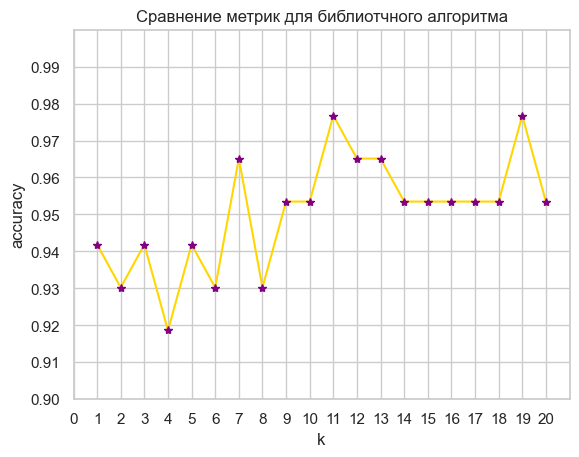

In [58]:
plt.plot(range(1, 21), accur_per_k, 
         color='gold',
         marker='*', markersize=6,
         markerfacecolor='purple', markeredgecolor='purple')

#plt.legend()
plt.title("Сравнение метрик для библиотчного алгоритма")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 1))
plt.yticks(np.arange(0.90, 1, 0.01))
plt.xlim((0, 21))
plt.ylim((0.9, 1))
plt.show()

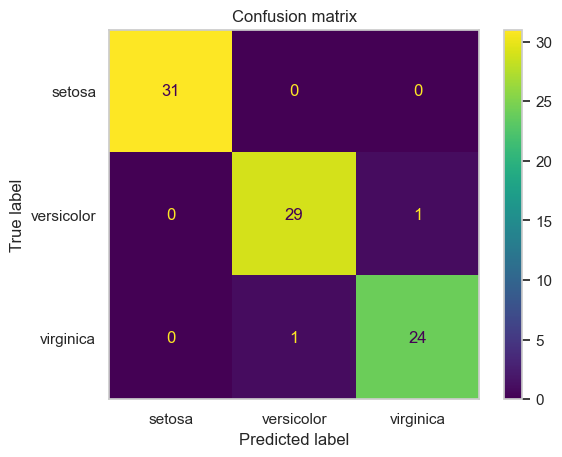

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(x_train, y_train)
cm = confusion_matrix(y_test, knn_model.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Confusion matrix")
plt.grid(False)
plt.show()

# Главные компоненты

In [60]:
# Импорт библиотек
import numpy as np
#import matplotlib.pyplot as plt
from sklearn import decomposition
#from sklearn import datasets

 # Загрузка данных
#centers = [[1, 1], [-1, -1], [1, -1]]
iris = datasets.load_iris()
X = iris.data
y = iris.target

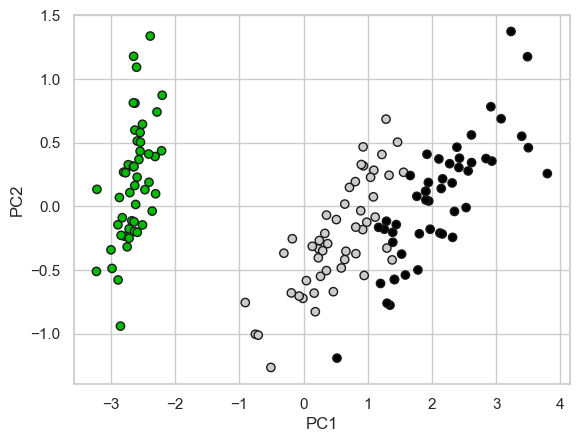

In [61]:
 # Преобразование данных датасета Iris, уменьшающее размерность до 2
pca = decomposition.PCA(n_components=2)
pca.fit(X)
X = pca.transform(X)
y = np.choose(y, [1, 2, 0]).astype(np.float32) #Перемаркировка классов
plt.clf()
plt.cla()
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.nipy_spectral, edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [164]:
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648]


print(pca.explained_variance_ratio_) показывает сколько информации (дисперсии) объясняет каждая главная компонента.
Например если выведет [0.92, 0.05] — это значит:

* 1-я компонента объясняет 92% всей информации в данных
* 2-я компонента — ещё 5%
* итого PCA из 2 компонент сохранил 97% информации, потеряв всего 3%

In [62]:
from sklearn.model_selection import train_test_split

size = 64

x_train, x_test, y_train, y_test = train_test_split(X[:, :],
                                                    iris['target'],
                                                    train_size=size,
                                                    random_state=808) # random_state - для воспроизводимости

print(f'X_train shape: {x_train.shape}, y_train shape: {y_train.shape},\n'
      f'X_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (64, 2), y_train shape: (64,),
X_test shape: (86, 2), y_test shape: (86,)


In [63]:
x_train_concat = np.concatenate((x_train, y_train.reshape(size, 1)), axis=1)
x_test_concat = np.concatenate((x_test, y_test.reshape(150-size, 1)), axis=1)
print(f'X_train shape: {x_train_concat.shape},\n'
      f'X_test shape: {x_test_concat.shape}')

X_train shape: (64, 3),
X_test shape: (86, 3)


In [64]:
pd.DataFrame(x_train_concat).head(5)

,0,1,2
0,-2.506947,0.645069,0.0
1,-2.997407,-0.341926,0.0
2,2.616676,0.343903,2.0
3,2.427818,0.378196,2.0
4,-2.888991,-0.144949,0.0


## Соседи. Рукописный метод

In [65]:
accur_per_norm = {"Манхэттэнская" : [], "Евклидова" : [], "Минковского" : [], "Чебышева" : []}

for norm in norms:
    for k in range(1, 21):
        predictions_temp = list()
        for x in range (len(x_test_concat)):
            neighbors = get_neighbors(x_train_concat, x_test_concat[x], norms[norm], k)
            result = prediction(neighbors)
            predictions_temp.append(result)
        accur_per_norm[norm].append(accuracy(x_test_concat, predictions_temp))

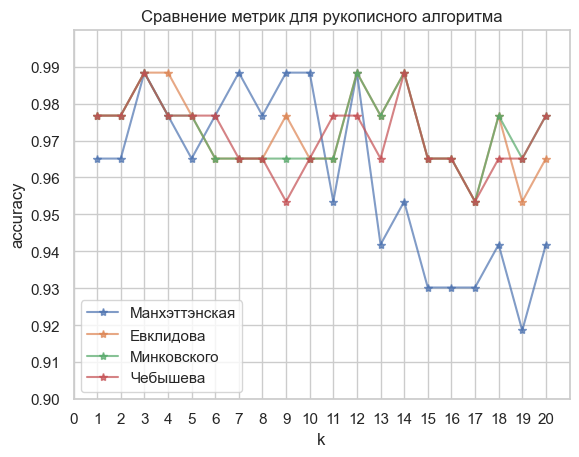

In [66]:
#for norm in norms:
#    plt.plot(range(1, 21), accur_per_norm[norm], marker='*', markersize=6, alpha=0.7, label=norm)
plt.plot(range(1, 21), accur_per_norm["Манхэттэнская"], marker='*', markersize=6, alpha=0.7, label="Манхэттэнская")
plt.plot(range(1, 21), accur_per_norm["Евклидова"], marker='*', markersize=6, alpha=0.7, label="Евклидова")
plt.plot(range(1, 21), accur_per_norm["Минковского"], marker='*', markersize=6, alpha=0.7, label="Минковского")
plt.plot(range(1, 21), accur_per_norm["Чебышева"], marker='*', markersize=6, alpha=0.7, label="Чебышева")

plt.legend()
plt.title("Сравнение метрик для рукописного алгоритма")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 1))
plt.yticks(np.arange(0.90, 1, 0.01))
plt.xlim((0, 21))
plt.ylim((0.9, 1))
plt.show()

## Соседи. Библиотечный метод

In [67]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_model = knn.fit(x_train, y_train)

knn_predictions = knn.predict(x_test)
knn_predictions

array([0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 2, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1, 0,
       2, 1, 2, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1, 0, 1, 0, 2, 0,
       0, 0, 0, 0, 0, 1, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 1, 2, 1, 0, 1, 1,
       1, 2, 0, 0, 2, 0, 1, 1, 1, 1, 2, 2, 1, 1, 0, 0, 0, 0, 2, 0])

In [68]:
accur_per_k = list()

for k in range (1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    knn_predictions = knn.predict(x_test)
    accur_per_k.append(accuracy(x_test_concat, knn_predictions))

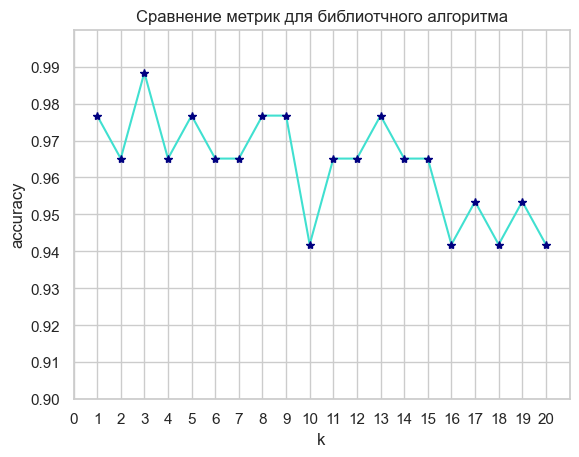

In [69]:
plt.plot(range(1, 21), accur_per_k, 
         color='turquoise',
         marker='*', markersize=6,
         markerfacecolor='navy', markeredgecolor='navy')

#plt.legend()
plt.title("Сравнение метрик для библиотчного алгоритма")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.xticks(range(0, 21, 1))
plt.yticks(np.arange(0.90, 1, 0.01))
plt.xlim((0, 21))
plt.ylim((0.9, 1))
plt.show()

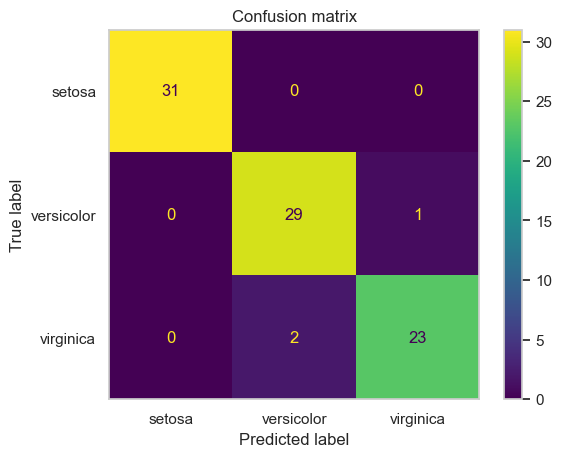

In [70]:
knn_model = KNeighborsClassifier(n_neighbors=11)
knn_model.fit(x_train, y_train)
cm = confusion_matrix(y_test, knn_model.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Confusion matrix")
plt.grid(False)
plt.show()